# Memorization Label Prediction and Independent Variables Effect Analysis

## Setup

### Environment Setup

In [1]:
# import sys
# import subprocess

# # packages = open("requirements.txt").read().splitlines()
# packages = open("requirements2.txt").read().splitlines()
# print(f"🔄 Synchronizing environment dependencies: {packages}...")
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade"] + packages)
# print("✅ Synchronization complete. Packages are now compatible.")

In [106]:
from openai import OpenAI
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold
from sklearn.linear_model import LassoCV, LinearRegression, LogisticRegressionCV
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, confusion_matrix, auc, RocCurveDisplay, roc_curve, mean_absolute_error, mean_squared_error, r2_score, classification_report, ConfusionMatrixDisplay, cohen_kappa_score, make_scorer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.pipeline import Pipeline
import shap
from xgboost import XGBClassifier, XGBRegressor
from pulearn import ElkanotoPuClassifier
from sklearn.cluster import KMeans
from scipy import stats
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D
import uuid
import json
from pathlib import Path
from utils import BASE_DIR, INPUT_DIR, PROMPTS_DIR, OUTPUTS_DIR, API_INPUT_DIR, API_OUTPUT_DIR, API_JOBS_DIR, create_prompt, create_batch_input_file, \
    send_input_to_api, wait_for_batch_completion, retrieve_api_output, output_jsonl_to_dataframe, run_whole_batch_process

API_KEY = os.getenv("OPENAI_API_KEY_UNIVERSITY")
client = OpenAI(api_key=API_KEY)

df_filename = "combined_questions_with_classification.xlsx"

### Helper Functions

In [3]:
def load_df(file_name: str, file_dir: Path=INPUT_DIR) -> pd.DataFrame:
    file_path = file_dir / file_name
    if file_path.suffix == ".pkl":
        return pd.read_pickle(file_path)
    elif file_path.suffix == ".xlsx":
        return pd.read_excel(file_path)
    elif file_path.suffix == ".csv":
        return pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format")
    
def merge_dfs(df1: pd.DataFrame, df2: pd.DataFrame, on_left: str="id", on_right="custom_id", how: str="left", df1_columns=None, df2_columns=None) -> pd.DataFrame:
    if df1_columns is not None:
        df1 = df1[df1_columns + [on_left]]
    if df2_columns is not None:
        df2 = df2[df2_columns + [on_right]]
    merged_df = pd.merge(df1, df2, left_on=on_left, right_on=on_right, how=how, suffixes=('_left', '_right'))
    return merged_df

extract_answer_text = lambda response: (
    response.get("body", {})
            .get("choices", [{}])[0]
            .get("message", {})
            .get("content")
    if isinstance(response, dict) else None
)

In [18]:
def expand_labels_to_one_hot_internal(df, task_type_schema, subject_schema):
    """
    Expands task types into primary/secondary one-hots, and subjects into 
    Level 2 (Primary Subject) and Level 3 (Secondary Subject) one-hots.
    """
    
    # 1. Prepare Task Type Columns
    task_names = [label['name'] for label in task_type_schema['labels']]
    id_to_name = {label['id']: label['name'] for label in task_type_schema['labels']}
    
    # 2. Prepare Subject Hierarchies
    # Map Level 3 (tag) -> Level 2 (category)
    tag_to_primary_map = {}
    all_level2_subjects = []
    all_level3_subjects = []
    
    for domain, categories in subject_schema.items():
        for category_name, tags in categories.items():
            all_level2_subjects.append(category_name)
            for tag in tags:
                tag_to_primary_map[tag] = category_name
                all_level3_subjects.append(tag)

    print(f"Identified {len(task_names)} unique task types.")
    # Initialize columns with 0
    for name in task_names:
        df[f'task_primary_{name}'] = 0
        df[f'task_secondary_{name}'] = 0
        
    for l2 in set(all_level2_subjects):
        df[f'sub_primary_{l2}'] = 0
        
    for l3 in set(all_level3_subjects):
        df[f'sub_secondary_{l3}'] = 0

    # 3. Process Rows
    for idx, row in df.iterrows():
        # --- Task Types ---
        tt = row['task_type_labels']
        if isinstance(tt, str): tt = json.loads(tt)
        
        primary_id = tt.get('primary_task_type')
        if primary_id and primary_id in id_to_name:
            df.at[idx, f"task_primary_{id_to_name[primary_id]}"] = 1
        for sec in tt.get('secondary_task_types', []):
            if sec in id_to_name:
                df.at[idx, f"task_secondary_{id_to_name[sec]}"] = 1
            
        # --- Subjects ---
        st = row['subject_labels']
        if isinstance(st, str): st = json.loads(st)
        
        for tag in st.get('subject_tags', []):
            # Mark the Level 3 (Secondary) column
            df.at[idx, f"sub_secondary_{tag}"] = 1
            
            # Mark the corresponding Level 2 (Primary) column
            primary_cat = tag_to_primary_map.get(tag)
            if primary_cat:
                df.at[idx, f"sub_primary_{primary_cat}"] = 1
                
    return df

def extract_labels_to_one_hot(df):
    with open(INPUT_DIR / 'task_type_labels.json') as f: tt_schema = json.load(f)
    with open(INPUT_DIR / 'subject_labels.json') as f: sub_schema = json.load(f)
    df = expand_labels_to_one_hot_internal(df.copy(), tt_schema, sub_schema)
    return df

### Redo Labels

In [5]:
# df = load_df(df_filename)
# # df.drop(columns=['subject_labels', 'task_type_labels'], inplace=True, errors='ignore')  # drop old label columns if they exist

# df_labeled_subject = run_whole_batch_process("label_subject", "label_subject", df, "solution_english", system_prompt_filename="labeling_system_prompt_subject")
# df_labeled_task_type = run_whole_batch_process("label_task_type", "label_task_type", df, "question_english", system_prompt_filename="labeling_system_prompt_task_type")

# # df_labeled_subject = output_jsonl_to_dataframe("label_subject_output")
# # df_labeled_task_type = output_jsonl_to_dataframe("label_task_type_output")

# df_with_labels = merge_dfs(df, df_labeled_subject, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "subject_labels"})
# df_with_labels = df_with_labels.drop(columns=['custom_id'], errors='ignore')
# df_with_labels = merge_dfs(df_with_labels, df_labeled_task_type, on_left="id", on_right="custom_id", how="left", df2_columns=["answer_text"]).rename(columns={"answer_text": "task_type_labels"})
# df_with_labels = df_with_labels.drop(columns=['custom_id'], errors='ignore')


# df_with_labels.to_excel(INPUT_DIR / df_filename, index=False)


### Read and Process Dataframe

In [6]:
df = load_df(df_filename)
print("✅ Data loaded successfully.")

dist_ratio_threshold = 0.33
df['filter_out_by_threshold'] = df.apply(lambda row: row['dist_ratio'] > dist_ratio_threshold and row['likely_memorized_classification'] == 1, axis=1)
print(f"🔍 Applied distance ratio threshold of {dist_ratio_threshold}.")
print("DataFrame shape: ", df.shape)

✅ Data loaded successfully.
🔍 Applied distance ratio threshold of 0.33.
DataFrame shape:  (342, 29)


#### Filter Dataset

In [19]:
pred_df = df[~df['filter_out_by_threshold']].copy()
pred_df = pred_df[pred_df['dataset'] == 'exams_df']
print("DataFrame after filtering shape: ", pred_df.shape)

# for i in range(3):
#     # extract a random row['task_type_labels'] and row['subject_labels']
#     random_row = pred_df.sample(n=1)
#     print(f"Random row task_type_labels: {random_row['task_type_labels'].iloc[0]}")
#     print(f"Random row subject_labels: {random_row['subject_labels'].iloc[0]}")

DataFrame after filtering shape:  (208, 29)


#### Extract Task-Type, Subject Tags

In [20]:
pred_df = extract_labels_to_one_hot(pred_df)

Identified 16 unique task types.


C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\716066763.py:34: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'sub_secondary_{l3}'] = 0
C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\716066763.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.at[idx, f"sub_secondary_{tag}"] = 1
C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\716066763.py:55: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

In [21]:
print("Final Prediction DataFrame shape:", pred_df.shape)
print("Final Prediction DataFrame columns:")
# print columns nicely - after every 7 columns, print a new line
columns = pred_df.columns.tolist()
for i, col in enumerate(columns):
    if i % 7 == 0 and i > 0:
        print()  # newline
    print('\'' + col + '\'', end=", ")

Final Prediction DataFrame shape: (208, 179)
Final Prediction DataFrame columns:
'custom_id_left', 'id', 'dataset', 'source', 'likely_memorized_classification', 'avg_answer_distance', 'grade_std', 
'grade_mean', 'reasoning_tokens_std', 'reasoning_tokens_mean', 'dist_ratio', 'year', 'semester', 'moed', 
'question', 'section', 'points', 'question_hebrew', 'solution_hebrew', 'avg_score', 'std_score', 
'max_score', 'avg_score_norm', 'std_score_norm', 'question_english', 'solution_english', 'subject_labels', 'task_type_labels', 
'filter_out_by_threshold', 'task_primary_Design Data Structure', 'task_secondary_Design Data Structure', 'task_primary_Design Algorithm', 'task_secondary_Design Algorithm', 'task_primary_Design Randomized Algorithm', 'task_secondary_Design Randomized Algorithm', 
'task_primary_Prove Correctness', 'task_secondary_Prove Correctness', 'task_primary_Analyze Complexity', 'task_secondary_Analyze Complexity', 'task_primary_Exact Bound and Counting', 'task_secondary_Exact B

## Label Prediction

### Configuration

In [22]:
# # 1. Define Column Groups
# numeric_cols = ['avg_score_norm', 'std_score_norm']
# target_column = 'likely_memorized_classification'

# # 2. Define the 4 Model Variations
# # Each tuple represents: (Task Type Level, Subject Level)
# model_configs = {
#     "Model_1_Primary_Task_Primary_Sub": ('task_primary_', 'sub_primary_'),
#     "Model_2_Primary_Task_Secondary_Sub": ('task_primary_', 'sub_secondary_'),
#     "Model_3_Secondary_Task_Primary_Sub": ('task_secondary_', 'sub_primary_'),
#     "Model_4_Secondary_Task_Secondary_Sub": ('task_secondary_', 'sub_secondary_')
# }

# model_results = {}

# Configuration
target_col = 'likely_memorized_classification'
numeric_cols = ['avg_score_norm', 'std_score_norm']
hierarchies = {
    "TaskPri_SubPri": ('task_primary_', 'sub_primary_'),
    "TaskPri_SubSec": ('task_primary_', 'sub_secondary_'),
    "TaskSec_SubPri": ('task_secondary_', 'sub_primary_'),
    "TaskSec_SubSec": ('task_secondary_', 'sub_secondary_')
}

all_results = []

In [23]:
# print null values in pred_df, where null > 0
print("Null values in final DataFrame:")
null_counts = pred_df[numeric_cols + [target_col] + [col for col in pred_df.columns if col.startswith('task_') or col.startswith('sub_')]].isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

# present value counts for sub_secondary_Big-Ω sub_secondary_Big-Θ (only these 2 columns)
print("\nValue counts for 'sub_secondary_Big-Ω':")
print(pred_df['sub_secondary_Big-Ω'].value_counts())
print("\nValue counts for 'sub_secondary_Big-Θ':")
print(pred_df['sub_secondary_Big-Θ'].value_counts())

# 1. Fix Binary/One-Hot Nulls
# Identify all one-hot columns to ensure they are complete
binary_cols = [col for col in pred_df.columns if col.startswith(('task_', 'sub_'))]
pred_df[binary_cols] = pred_df[binary_cols].fillna(0)

Null values in final DataFrame:
avg_score_norm                          161
std_score_norm                          161
sub_secondary_Big-Ω                     200
sub_secondary_Upper/Lower Bounds        184
sub_secondary_Order-Statistic Trees     199
sub_secondary_BST                       190
sub_secondary_Non-Comparison Sorting    195
sub_secondary_lower-o-notation          204
sub_secondary_Big-Θ                     197
sub_secondary_Rotations                 207
sub_secondary_Geometric                 207
sub_secondary_Suffix Trees              205
sub_secondary_Uniform                   205
dtype: int64

Value counts for 'sub_secondary_Big-Ω':
sub_secondary_Big-Ω
1.0    8
Name: count, dtype: int64

Value counts for 'sub_secondary_Big-Θ':
sub_secondary_Big-Θ
1.0    11
Name: count, dtype: int64


In [24]:
# print null values in pred_df, where null > 0 after correction
print("Updated null values in final DataFrame:")
null_counts = pred_df[numeric_cols + [target_col] + [col for col in pred_df.columns if col.startswith('task_') or col.startswith('sub_')]].isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

Updated null values in final DataFrame:
avg_score_norm    161
std_score_norm    161
dtype: int64


### Possible Logistic Reression Models
Including different combinations of primary and secondary labels from task types, subjects. 
Applying Lasso (L1) regression and KFold cross validation to avoid overfitting.

In [26]:
# Ensure full table display
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

all_results = []

for h_name, (task_pre, sub_pre) in hierarchies.items():
    selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]
    
    variations = [
        {"name": f"{h_name}_AllData_NoScores", "df": pred_df, "cols": selected_one_hot},
        {"name": f"{h_name}_Subset_WithScores", "df": pred_df.dropna(subset=numeric_cols), "cols": selected_one_hot + numeric_cols}
    ]

    for var in variations:
        X = var['df'][var['cols']]
        y = var['df'][target_col]
        
        if len(X) < 10: continue 

        pipeline = Pipeline([
            ('interactions', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=StratifiedKFold(min(5, len(np.unique(y)))), 
                penalty='l1', 
                solver='liblinear', 
                scoring='roc_auc',
                max_iter=5000,
                random_state=42
            ))
        ])

        try:
            pipeline.fit(X, y)
            best_clf = pipeline.named_steps['clf']
            
            # 1. Get CV AUC Score (mean of the max scores across C values)
            auc_cv = np.mean(np.max(best_clf.scores_[1], axis=1))
            
            # 2. Get predictions to calculate other metrics correctly
            y_pred = pipeline.predict(X)
            
            acc = accuracy_score(y, y_pred)
            f1 = f1_score(y, y_pred) # Correct F1 calculation
            active_feats = (best_clf.coef_ != 0).sum()
            true_positive_rate = ((y == 1) & (y_pred == 1)).sum() / (y == 1).sum() if (y == 1).sum() > 0 else np.nan

            tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
            fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            
        except Exception as e:
            print(f"Error in {var['name']}: {e}")
            auc_cv, acc, f1, fnr, fpr, active_feats = np.nan, np.nan, np.nan, np.nan, np.nan, 0

        all_results.append({
            "Model_Name": var['name'],
            "Sample_Size": len(X),
            "Features_In": len(var['cols']),
            "Active_After_Lasso": active_feats,
            "CV_ROC_AUC": auc_cv,
            "Accuracy": acc,
            "F1_Score": f1,
            "False_Negative_Rate": fnr,
            "False_Positive_Rate": fpr
        })

results_df = pd.DataFrame(all_results)
display(results_df.sort_values(by="CV_ROC_AUC", ascending=False))

,Model_Name,Sample_Size,Features_In,Active_After_Lasso,CV_ROC_AUC,Accuracy,F1_Score,False_Negative_Rate,False_Positive_Rate
0,TaskPri_SubPri_AllData_NoScores,208,33,62,0.730040,0.841346,0.871595,0.118110,0.222222
2,TaskPri_SubSec_AllData_NoScores,208,117,93,0.725565,0.903846,0.921875,0.070866,0.135802
1,TaskPri_SubPri_Subset_WithScores,47,35,32,0.675070,0.936170,0.956522,0.029412,0.153846
5,TaskSec_SubPri_Subset_WithScores,47,35,27,0.666667,0.936170,0.955224,0.058824,0.076923
4,TaskSec_SubPri_AllData_NoScores,208,33,96,0.659907,0.850962,0.877470,0.125984,0.185185
6,TaskSec_SubSec_AllData_NoScores,208,117,121,0.649387,0.889423,0.906122,0.125984,0.086420
7,TaskSec_SubSec_Subset_WithScores,47,119,38,0.616246,0.914894,0.944444,0.000000,0.307692
3,TaskPri_SubSec_Subset_WithScores,47,119,43,0.573529,0.978723,0.985075,0.029412,0.000000


It seems TaskPri_SubSec_AllData_NoScores model acheived the best results. Let's examine the coefficients:

In [27]:
SELECTED_MODEL = "TaskPri_SubPri_AllData_NoScores"
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# 1. Isolate the specific configuration
# selected hierarchy is SELECTED_MODEL until the second underscore (not including) - as substring, e.g. TaskPri_SubPri from TaskPri_SubPri_Subset_WithScores
selected_hierarchy = SELECTED_MODEL.split('_Subset')[0].split('_AllData')[0]
task_pre, sub_pre = hierarchies[selected_hierarchy]
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]
df_in_use = pred_df.copy()
if "WithScores" in SELECTED_MODEL:
    df_in_use = pred_df.dropna(subset=numeric_cols)
    selected_one_hot += numeric_cols

# print(f"Selected Model: {SELECTED_MODEL}")
# print(f"Selected Hierarchy: {selected_hierarchy}")
# print(f"Selected One-Hot Columns: {selected_one_hot}")
X_model = df_in_use[selected_one_hot]
y_model = df_in_use[target_col]

# 2. Re-fit or access your existing pipeline for this specific model
# (Assuming 'pipeline' is the one fitted for TaskPri_SubSec_AllData_NoScores)
pipeline.fit(X_model, y_model)

# 3. Extract components
intercept = pipeline.named_steps['clf'].intercept_[0]
coefficients = pipeline.named_steps['clf'].coef_[0]
feature_names = pipeline.named_steps['interactions'].get_feature_names_out(selected_one_hot)

# 4. Filter for non-zero (active) features
active_indices = np.where(coefficients != 0)[0]
active_coeffs = coefficients[active_indices]
active_names = feature_names[active_indices]

# 5. Format the formula
formula_parts = [f"{intercept:.4f}"]
for coeff, name in zip(active_coeffs, active_names):
    sign = "+" if coeff >= 0 else "-"
    formula_parts.append(f" {sign} ({abs(coeff):.4f} * {name})")

full_formula = "".join(formula_parts)

print(f"--- Log-Odds Formula for {target_col} ---")
print(f"logit(p) = {full_formula}")

# Create a DataFrame for easier inspection
formula_df = pd.DataFrame({
    'Feature': active_names,
    'Coefficient': active_coeffs
}).sort_values(by='Coefficient', key=abs, ascending=False)

display(formula_df)

--- Log-Odds Formula for likely_memorized_classification ---
logit(p) = 0.5239 - (0.0246 * task_primary_Solve Recurrence) - (0.3727 * task_primary_Asymptotic Reasoning) - (0.1049 * task_primary_Prove Lower Bound) + (0.0735 * task_primary_Construct Counterexample) + (0.2514 * task_primary_Augment Existing Data Structure) - (0.8436 * task_primary_Select Answer and Justify) - (0.0059 * sub_primary_Selection) + (0.0574 * sub_primary_Expected) - (0.0455 * sub_primary_Recursion) + (0.0871 * task_primary_Design Data Structure sub_primary_Arrays & Lists) + (0.1539 * task_primary_Design Data Structure sub_primary_Hashing) + (0.0054 * task_primary_Design Data Structure sub_primary_Sorting) + (0.0095 * task_primary_Design Data Structure sub_primary_Heaps / Priority Queues) - (0.0598 * task_primary_Design Algorithm sub_primary_Hashing) + (0.0778 * task_primary_Design Algorithm sub_primary_Heaps / Priority Queues) + (0.0159 * task_primary_Design Algorithm sub_primary_Discrete Math) - (0.0688 * task

,Feature,Coefficient
5,task_primary_Select Answer and Justify,-0.843632
17,task_primary_Design Algorithm sub_primary_Asymptotic,0.378531
1,task_primary_Asymptotic Reasoning,-0.372663
54,sub_primary_Selection sub_primary_Asymptotic,-0.275862
46,sub_primary_Arrays & Lists sub_primary_Expected,0.264069
4,task_primary_Augment Existing Data Structure,0.251386
61,sub_primary_Asymptotic sub_primary_Recurrences,-0.242409
50,sub_primary_Tree Ops sub_primary_Expected,-0.220538
58,sub_primary_Sorting sub_primary_Recurrences,-0.211858
42,sub_primary_Trees sub_primary_Tree Ops,0.196272


C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\1057215390.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Total_Effect', y='Feature', palette=colors)


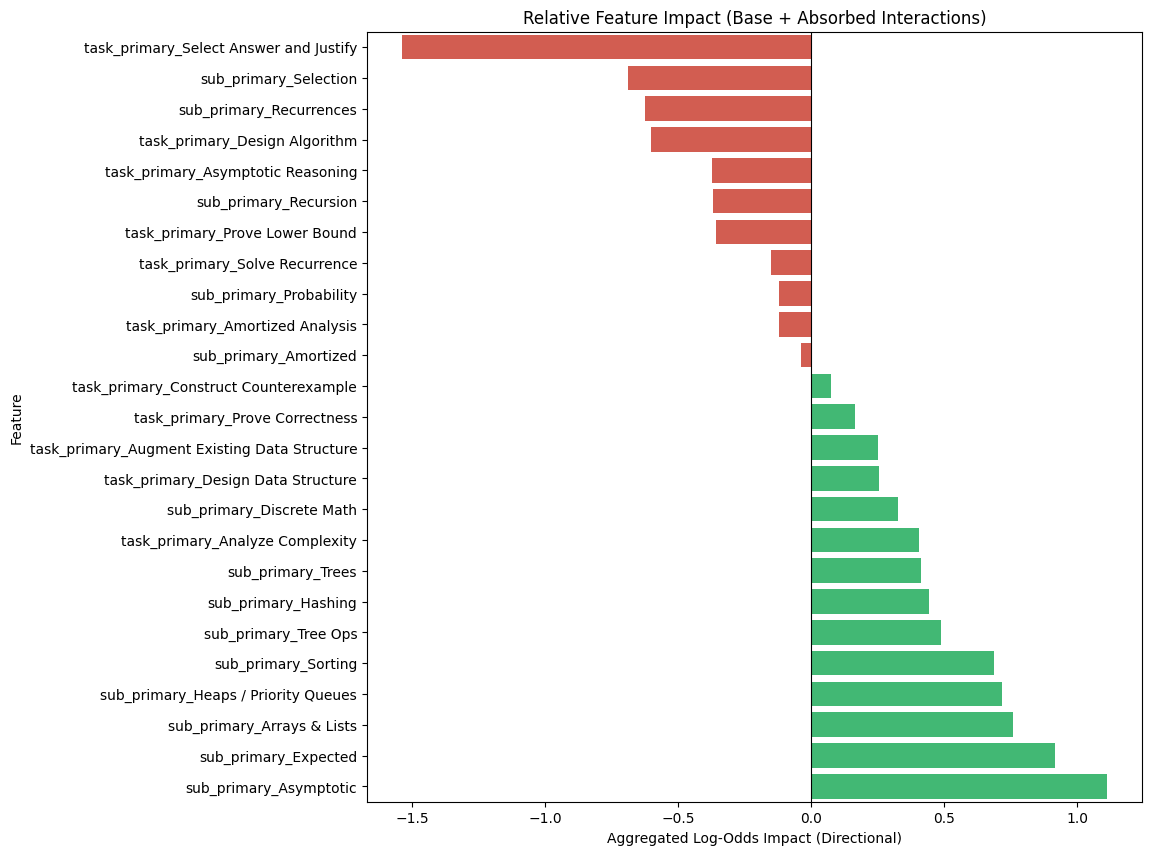

In [28]:
def plot_feature_importance_with_interactions(pipeline, base_features):
    # 1. Extract coefficients and names
    coefs = pipeline.named_steps['clf'].coef_[0]
    all_names = pipeline.named_steps['interactions'].get_feature_names_out(base_features)
    
    # 2. Map magnitudes to base features
    feature_effects = {feat: {'magnitude': 0, 'direction': 0} for feat in base_features}
    
    for coef, name in zip(coefs, all_names):
        if coef == 0: continue
        
        # Check which base features are part of this (base or interaction)
        for base in base_features:
            if base in name:
                feature_effects[base]['magnitude'] += abs(coef)
                # Direction is dictated by the base feature's own sign if available, 
                # or the sign of the interaction
                if base == name:
                    feature_effects[base]['direction'] = np.sign(coef)
                elif feature_effects[base]['direction'] == 0:
                    feature_effects[base]['direction'] = np.sign(coef)

    # 3. Convert to DataFrame for plotting
    plot_df = pd.DataFrame([
        {'Feature': k, 'Total_Effect': v['magnitude'] * v['direction'], 'Abs_Magnitude': v['magnitude']}
        for k, v in feature_effects.items() if v['magnitude'] > 0
    ]).sort_values(by='Total_Effect')

    # 4. Create Plot
    plt.figure(figsize=(10, len(plot_df) * 0.4))
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in plot_df['Total_Effect']]
    
    sns.barplot(data=plot_df, x='Total_Effect', y='Feature', palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Relative Feature Impact (Base + Absorbed Interactions)')
    plt.xlabel('Aggregated Log-Odds Impact (Directional)')
    plt.show()

# Usage
plot_feature_importance_with_interactions(pipeline, selected_one_hot)

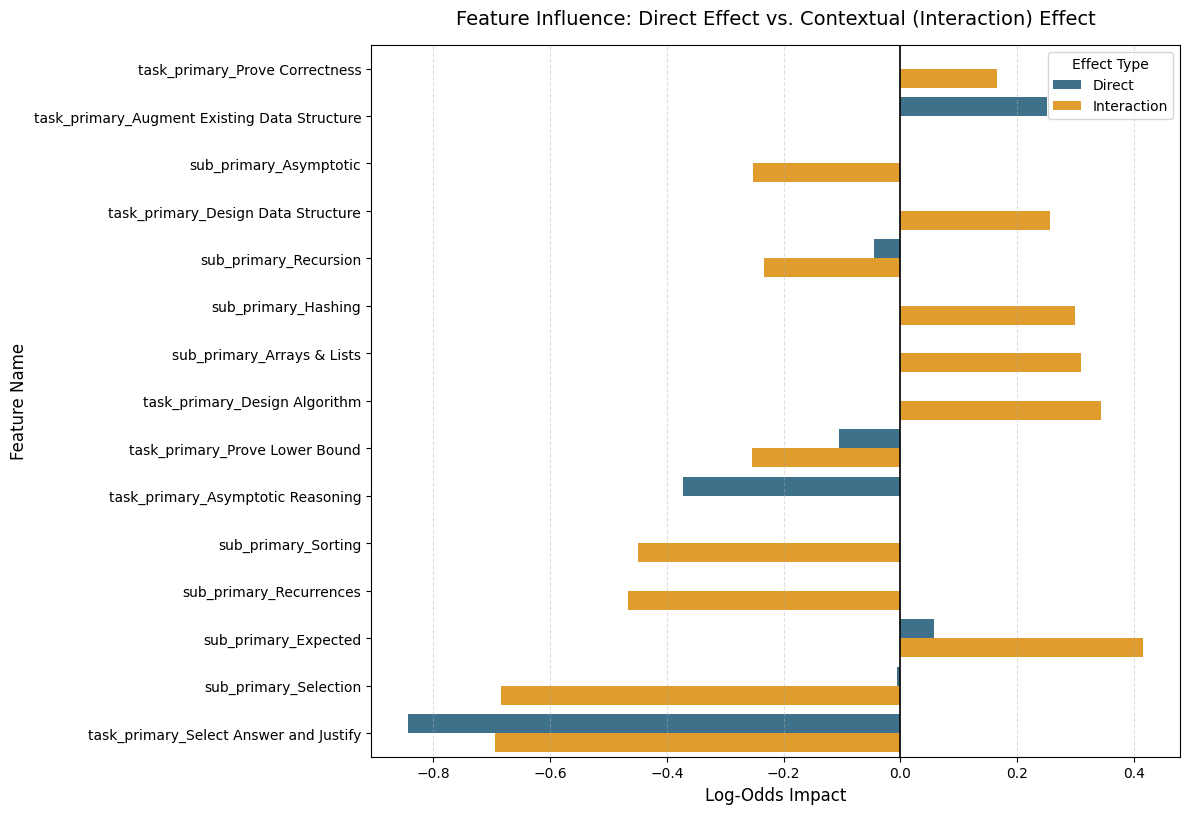

In [33]:
def plot_direct_vs_interaction_relation(pipeline, base_features, top_n=15):
    """
    Creates a grouped bar chart comparing direct vs interaction effects,
    colored by direct / indirect effect
    """
    # 1. Extract coefficients and names from the pipeline
    coefs = pipeline.named_steps['clf'].coef_[0]
    all_names = pipeline.named_steps['interactions'].get_feature_names_out(base_features)

    base_set = set(base_features)

    # 2. Map effects to base features
    effect_tracker = {feat: {'Direct': 0.0, 'Interaction': 0.0} for feat in base_features}

    for coef, name in zip(coefs, all_names):
        if coef == 0:
            continue

        if name in base_set:
            # Direct effect — exact match against known base features
            effect_tracker[name]['Direct'] = coef
        else:
            # Interaction — PolynomialFeatures joins feature names with " ", so split
            # by trying all known base features as prefix (handles names with spaces)
            matched = []
            for f in base_features:
                if name.startswith(f + ' '):
                    remainder = name[len(f) + 1:]
                    if remainder in base_set:
                        matched = [f, remainder]
                        break
            for f in matched:
                effect_tracker[f]['Interaction'] += coef

    # 3. Prepare DataFrame for plotting
    plot_data = []
    for feat, effects in effect_tracker.items():
        total_abs = abs(effects['Direct']) + abs(effects['Interaction'])
        if total_abs > 0:
            plot_data.append({'Feature': feat, 'Type': 'Direct',      'Value': effects['Direct'],      'Total': total_abs})
            plot_data.append({'Feature': feat, 'Type': 'Interaction',  'Value': effects['Interaction'], 'Total': total_abs})

    df_plot = pd.DataFrame(plot_data)

    # Top N by total abs magnitude; ascending=True so seaborn renders most dominant at top
    top_feats = (
        df_plot.drop_duplicates('Feature')
        .nlargest(top_n, 'Total')
        .sort_values('Total', ascending=True)['Feature']
        .tolist()
    )
    df_plot = df_plot[df_plot['Feature'].isin(top_feats)]

    # 4. Generate the Visualization — smaller per-bar height to fit more items
    fig_height = max(5, len(top_feats) * 0.55)
    plt.figure(figsize=(12, fig_height))

    # Fixed palette keyed by Type — distinguishes Direct vs Interaction
    type_palette = {'Direct': '#337796', 'Interaction': '#ffa310'}

    ax = sns.barplot(
        data=df_plot,
        y='Feature',
        x='Value',
        hue='Type',
        order=top_feats,
        palette=type_palette,
        dodge=True
    )

    plt.axvline(0, color='black', linewidth=1.2)
    plt.title('Feature Influence: Direct Effect vs. Contextual (Interaction) Effect', fontsize=14, pad=15)
    plt.xlabel('Log-Odds Impact', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    ax.legend(title='Effect Type', loc='best')
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Usage
plot_direct_vs_interaction_relation(pipeline, selected_one_hot, top_n=15)

### XGBoost Classifier

#### Hyperparameter Search

In [38]:
# 1. Prepare Data for TaskPri_SubSec
# Ensure your column prefixes match your latest dataframe state
task_pre, sub_pre = "task_primary_", "sub_secondary_"
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]

X = pred_df[selected_one_hot]
y = pred_df['likely_memorized_classification']

# 1. Define the Pipeline
# FIXED: learning_rate=0.05 moved to the classifier definition
pipeline = Pipeline([
    ('interactions', PolynomialFeatures(interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        learning_rate=0.05, 
        use_label_encoder=False, 
        eval_metric='logloss', 
        random_state=42
    ))
])

# 2. Define the Grid
# Degree 3 is removed to prevent feature explosion (6,000+ columns vs 208 rows)
param_grid = {
    'interactions__degree': [1, 2],
    'clf__max_depth': [2, 3],
    'clf__n_estimators': [50, 100, 150] # Expanded slightly since LR is fixed low
}

# 3. Execute Exhaustive Search
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=StratifiedKFold(5), 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)

# Output Results
print(f"Best Degree: {grid_search.best_params_['interactions__degree']}")
print(f"Fixed Learning Rate: 0.05")
print(f"Best Max Depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best N Estimators: {grid_search.best_params_['clf__n_estimators']}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

Best Degree: 1
Fixed Learning Rate: 0.05
Best Max Depth: 2
Best N Estimators: 100
Best AUC: 0.7650


c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:47:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Plotting Best Model Results

In [39]:
# Define the best parameters
best_params = {
    'learning_rate': 0.05,
    'max_depth': 2,
    'n_estimators': 100,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42
}

# Build the pipeline with Degree 1 (no interactions)
best_model_pipeline = Pipeline([
    ('interactions', PolynomialFeatures(degree=1, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(**best_params))
])

best_model_pipeline.fit(X, y)

c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:48:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('interactions',
                 PolynomialFeatures(degree=1, include_bias=False,
                                    interaction_only=True)),
                ('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               f...s=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

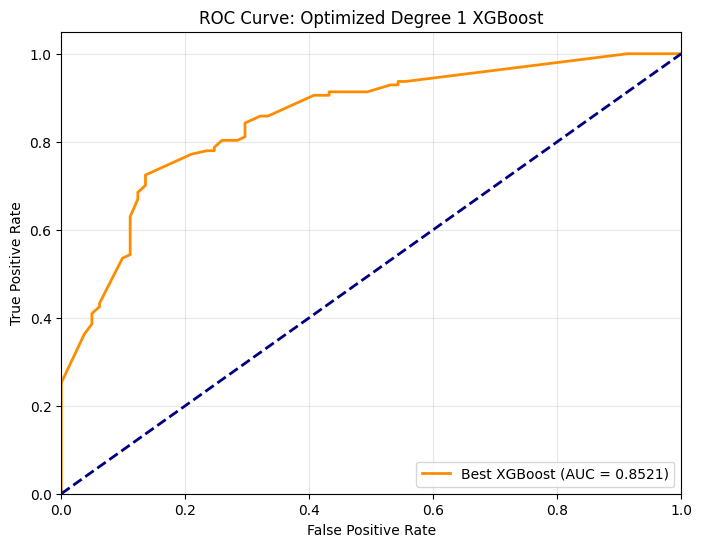

In [40]:
# Calculate probabilities
y_prob = best_model_pipeline.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Best XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Optimized Degree 1 XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\923100317.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


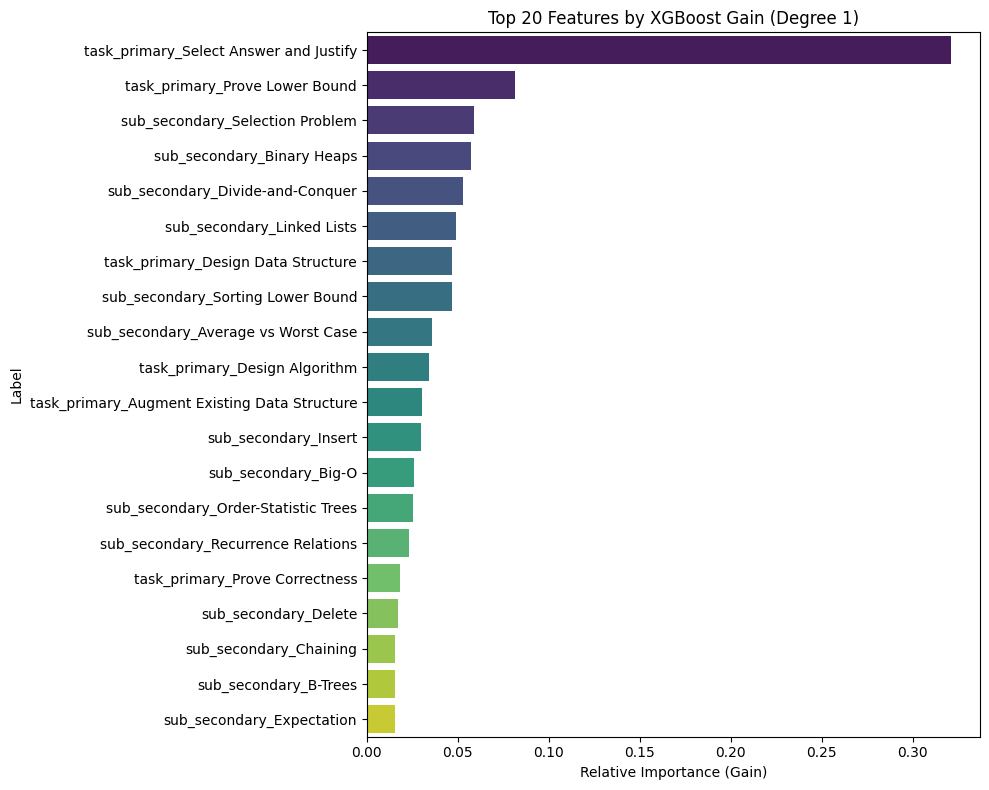

In [41]:
# Extract importances and names
importances = best_model_pipeline.named_steps['clf'].feature_importances_
feature_names = best_model_pipeline.named_steps['interactions'].get_feature_names_out(selected_one_hot)

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20) # Top 20 features

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Features by XGBoost Gain (Degree 1)')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

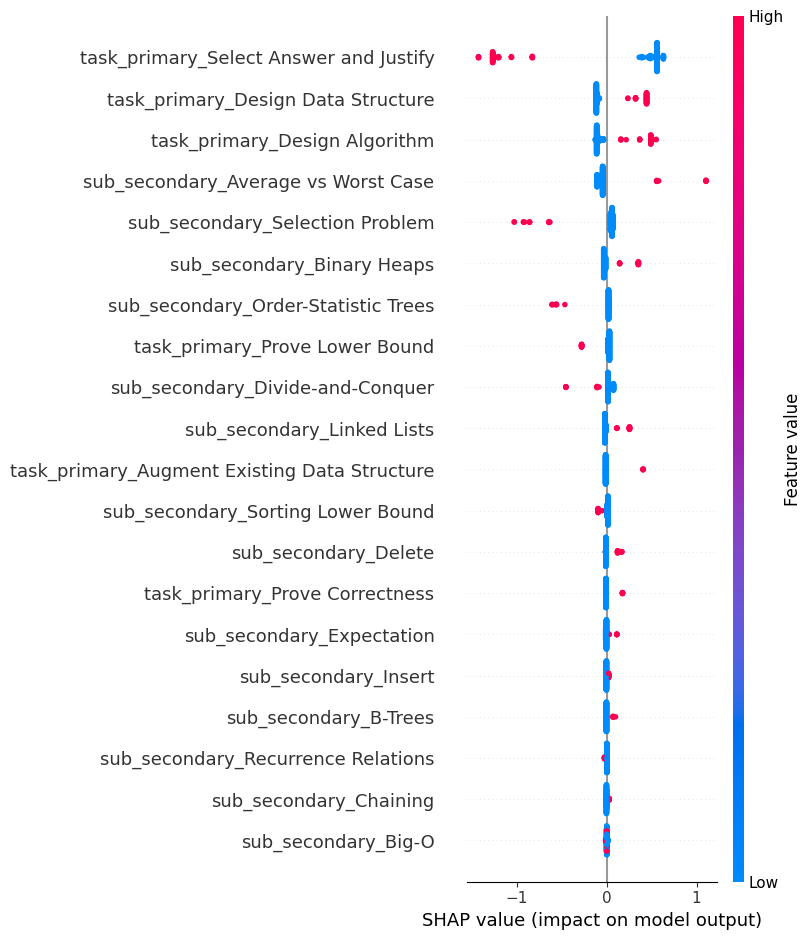

In [42]:
# 1. Transform the data through the pipeline's preprocessors
# Since Degree=1, this just scales the original features
X_transformed = best_model_pipeline.named_steps['scaler'].transform(
    best_model_pipeline.named_steps['interactions'].transform(X)
)

# 2. Calculate SHAP values for the XGBoost model
explainer = shap.TreeExplainer(best_model_pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_transformed)

# 3. Summary Plot: This shows magnitude AND direction
# Points to the right (positive) push toward 'Memorized' (1)
# Points to the left (negative) push toward 'Non-Memorized' (0)
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

c:\projects\LLMsForEducation\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\projects\LLMsForEducation\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\331958973.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_signed, x='Signed_Impact', y='Feature', palette=colors)


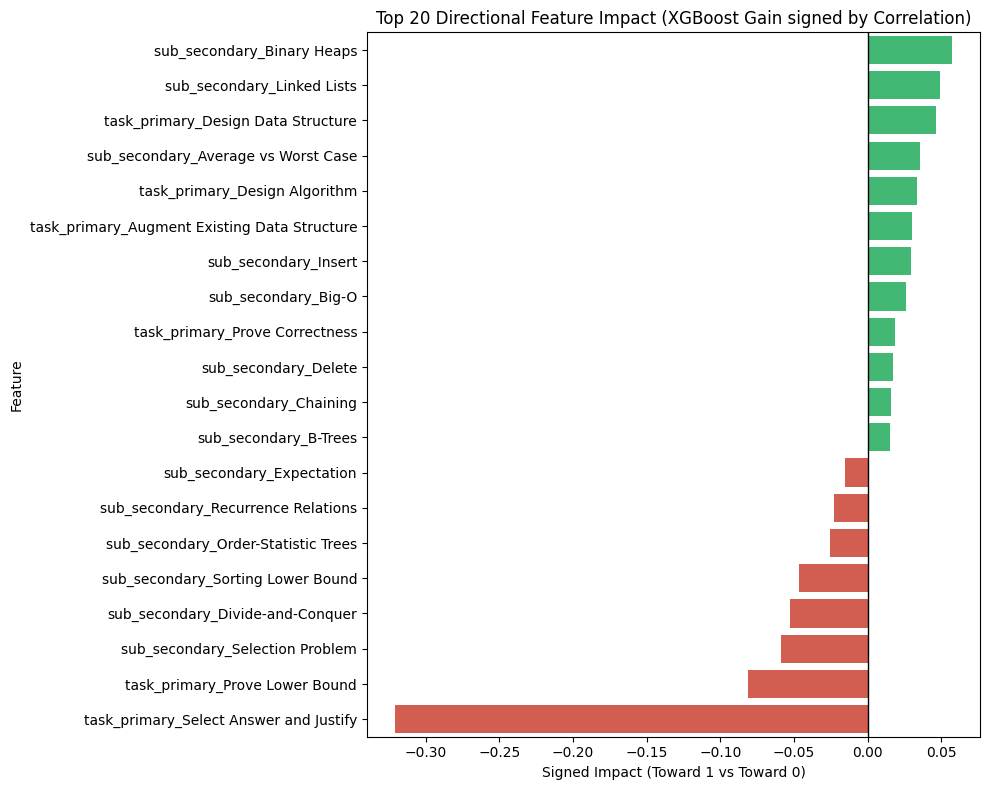

In [43]:
# 1. Calculate Correlation Direction
# We check if the feature is positively or negatively correlated with the target
correlations = X[selected_one_hot].corrwith(y)

# 2. Create Signed Importance DataFrame
signed_importance = pd.DataFrame({
    'Feature': feature_names,
    'Gain': importances,
    'Direction': [1 if correlations[f] > 0 else -1 for f in selected_one_hot]
})

signed_importance['Signed_Impact'] = signed_importance['Gain'] * signed_importance['Direction']

# 3. Filter for 20 most significant features
# We sort by the absolute magnitude (Gain) to find the 20 most powerful predictors
top_20_signed = signed_importance.sort_values(by='Gain', ascending=False).head(20)

# Re-sort the top 20 by the Signed_Impact for a clean diverging visual
top_20_signed = top_20_signed.sort_values(by='Signed_Impact', ascending=False)

# 4. Plot
plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_20_signed['Signed_Impact']]

sns.barplot(data=top_20_signed, x='Signed_Impact', y='Feature', palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 20 Directional Feature Impact (XGBoost Gain signed by Correlation)')
plt.xlabel('Signed Impact (Toward 1 vs Toward 0)')
plt.tight_layout()
plt.show()

#### Checking if including grade stats helps performance - it doesn't...

In [44]:
# 1. Prepare Data for TaskPri_SubSec
task_pre, sub_pre = "task_primary_", "sub_secondary_"
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))] + numeric_cols

X = pred_df[selected_one_hot]
y = pred_df['likely_memorized_classification']

# 1. Define the Pipeline
# We keep interaction_only=True to focus on relationships between different labels
pipeline = Pipeline([
    # ('interactions', PolynomialFeatures(interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# 2. Define the Grid
# We include 'degree' here to see if triplets (Degree 3) add value or just overfit
param_grid = {
    # 'interactions__degree': [1, 2, 3],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 4],
    'clf__n_estimators': [50, 100]
}

# 3. Execute Exhaustive Search
# StratifiedKFold is essential here to maintain label balance in the 208 rows
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=StratifiedKFold(5), 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)

# print(f"Best Degree: {grid_search.best_params_['interactions__degree']}")
print(f"Best Learning Rate: {grid_search.best_params_['clf__learning_rate']}")
print(f"Best Max Depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best N Estimators: {grid_search.best_params_['clf__n_estimators']}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

Best Learning Rate: 0.05
Best Max Depth: 2
Best N Estimators: 50
Best AUC: 0.7619


c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:49:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Cluster-Specific Analyses

### Unlikely Memorized Cluster

#### Correlation between LLM's and Students Grade STD, Mean 

--- Stats for student_performance_avg vs llm_performance_avg ---
Pearson Correlation: 0.0011
Spearman (Rank) Correlation: -0.0907
P-value: 0.9950
R-squared: 0.0000
Linear Eq: y = 0.0105x + 84.4272

--- Stats for student_performance_std vs llm_performance_std ---
Pearson Correlation: 0.2233
Spearman (Rank) Correlation: 0.2963
P-value: 0.2043
R-squared: 0.0499
Linear Eq: y = 0.9739x + 2.5474



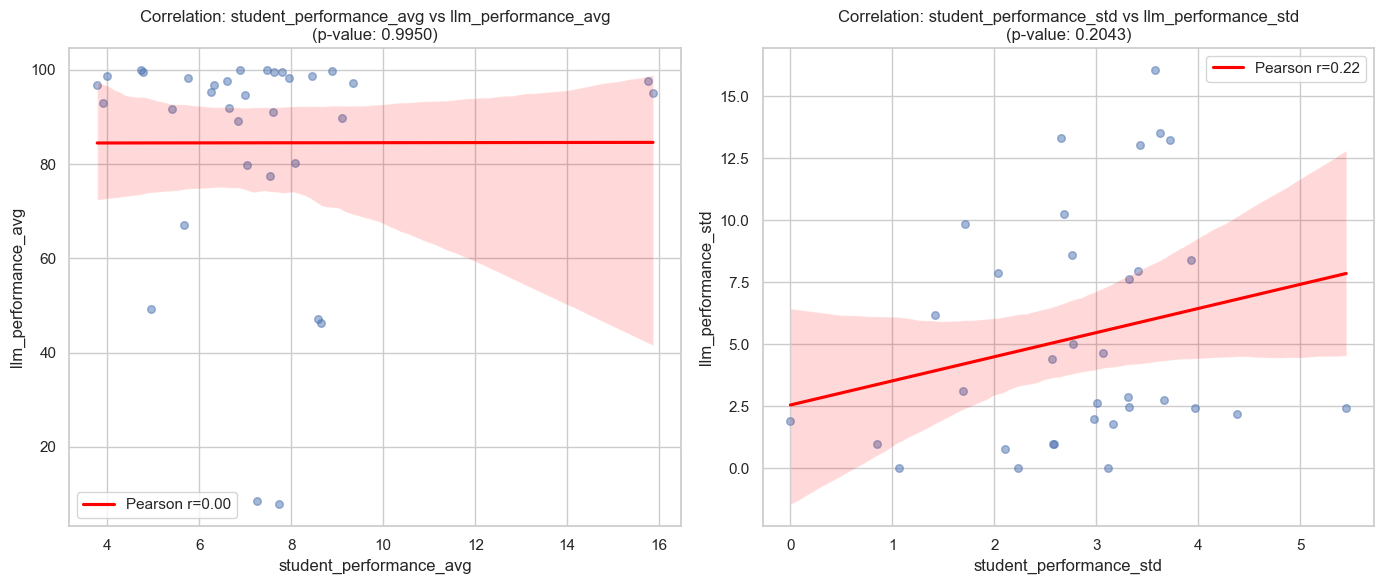

In [114]:
unlikely_memorized_df = pred_df[pred_df['likely_memorized_classification'] == 1].copy()
unlikely_memorized_df = unlikely_memorized_df[unlikely_memorized_df['avg_score'].notnull() & unlikely_memorized_df['std_score'].notnull()]
unlikely_memorized_df.rename(columns={'avg_score': 'student_performance_avg', 'std_score': 'student_performance_std', 'grade_mean': 'llm_performance_avg', 'grade_std': 'llm_performance_std'}, inplace=True)
corr_cols = [('student_performance_avg', 'llm_performance_avg'), ('student_performance_std', 'llm_performance_std')]

def analyze_correlations(df, pairs):
    # Set the visual style
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, len(pairs), figsize=(14, 6))
    
    for i, (x_col, y_col) in enumerate(pairs):
        # Drop NaNs for the specific calculation
        valid_data = df[[x_col, y_col]].dropna()
        x = valid_data[x_col]
        y = valid_data[y_col]
        
        # Calculate Statistics
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
        pearson_r, _ = stats.pearsonr(x, y)
        spearman_r, _ = stats.spearmanr(x, y)
        
        # Regression Plot
        sns.regplot(x=x_col, y=y_col, data=valid_data, ax=axes[i], 
                    scatter_kws={'alpha':0.5, 's':30}, 
                    line_kws={'color':'red', 'label':f'Pearson r={pearson_r:.2f}'})
        
        # Aesthetics
        axes[i].set_title(f"Correlation: {x_col} vs {y_col}\n(p-value: {p_value:.4f})")
        axes[i].legend()
        
        # Print Detailed Stats
        print(f"--- Stats for {x_col} vs {y_col} ---")
        print(f"Pearson Correlation: {pearson_r:.4f}")
        print(f"Spearman (Rank) Correlation: {spearman_r:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"R-squared: {r_value**2:.4f}")
        print(f"Linear Eq: y = {slope:.4f}x + {intercept:.4f}\n")

    plt.tight_layout()
    plt.show()

# Run the analysis
analyze_correlations(unlikely_memorized_df, corr_cols)


### Likely Memorized Cluster

In [45]:
likely_memorized_pred_df = pred_df[pred_df['likely_memorized_classification'] == 1].copy()
print("DataFrame of likely memorized questions shape:", likely_memorized_pred_df.shape)

DataFrame of likely memorized questions shape: (127, 179)


#### LLM's Grade Mean Prediction

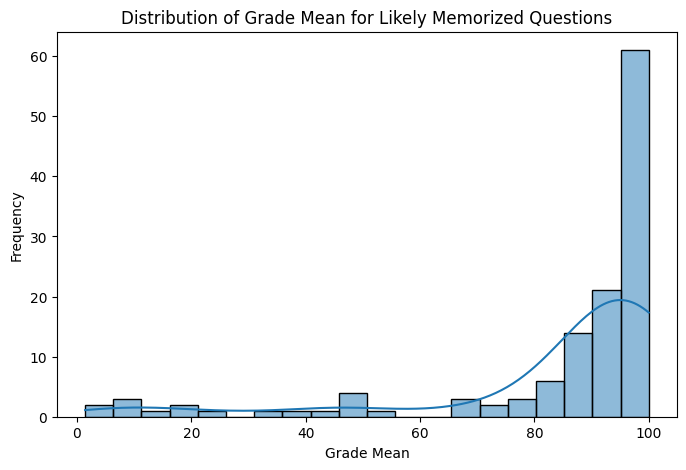

In [46]:
target_col = 'grade_mean'
# show distribution of grade_mean in likely_memorized_pred_df
plt.figure(figsize=(8, 5))
sns.histplot(likely_memorized_pred_df[target_col], bins=20, kde=True)
plt.title('Distribution of Grade Mean for Likely Memorized Questions')
plt.xlabel('Grade Mean')
plt.ylabel('Frequency')
plt.show()

##### Linear Regression

In [52]:
task_pre, sub_pre = "task_primary_", "sub_primary_"
selected_one_hot = [c for c in likely_memorized_pred_df.columns if c.startswith((task_pre, sub_pre))]
X = likely_memorized_pred_df[selected_one_hot]
y = likely_memorized_pred_df[target_col]

# 1. Define the Pipeline
# We keep the scaler to ensure any interpretation of "magnitude" is standardized
ols_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

# 2. Fit the model
ols_pipeline.fit(X, y)

# 3. Get Predictions
y_pred = ols_pipeline.predict(X)

# 4. Calculate Metrics
n = len(y)
p = X.shape[1]
r2 = r2_score(y, y_pred)
# Adjusted R2 calculation
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"--- OLS Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")
print(f"R²:   {r2:.4f}")
print(f"Adjusted R²: {adj_r2:.4f}")

--- OLS Linear Regression Performance ---
MAE:  15.8503
RMSE: 22.7411
R²:   0.1286
Adjusted R²: -0.1807


C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\4089531555.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_df, x='Coefficient', y='Feature', palette=colors)


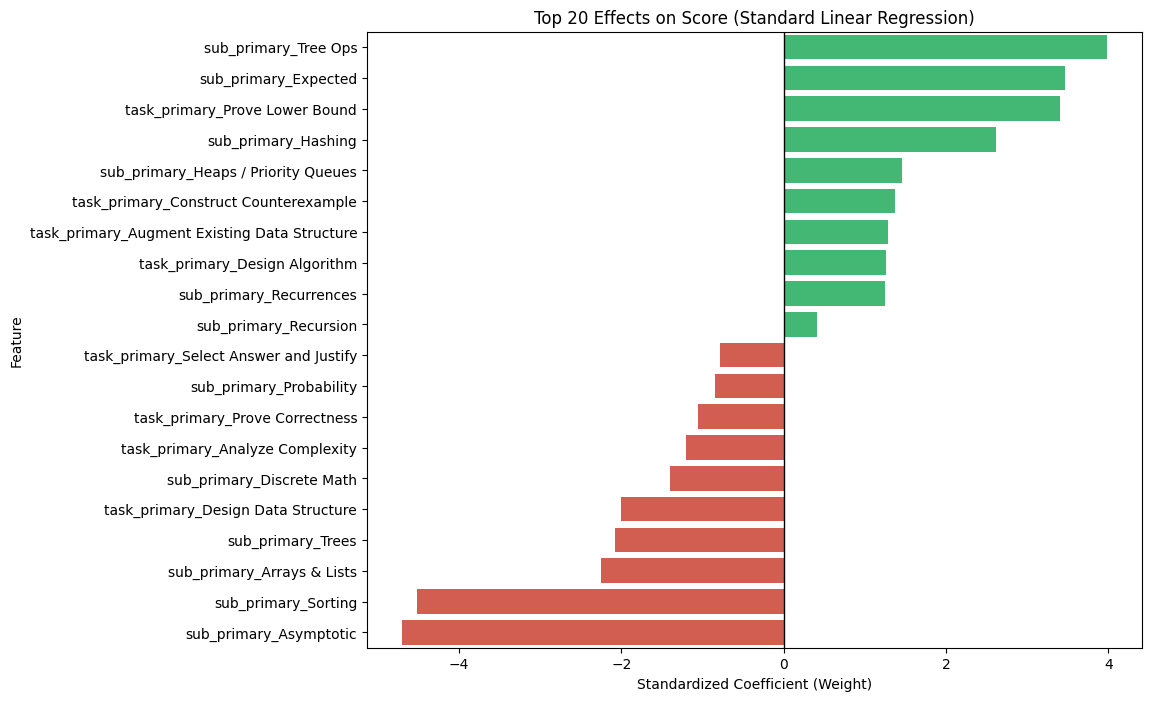

In [53]:
# Extract coefficients
coefs = ols_pipeline.named_steps['model'].coef_
importance_df = pd.DataFrame({
    'Feature': selected_one_hot,
    'Coefficient': coefs
})

# Sort by absolute magnitude to find the most "impactful" labels
importance_df['abs_coef'] = importance_df['Coefficient'].abs()
top_20_df = importance_df.sort_values(by='abs_coef', ascending=False).head(20)
top_20_df = top_20_df.sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in top_20_df['Coefficient']]
sns.barplot(data=top_20_df, x='Coefficient', y='Feature', palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 20 Effects on Score (Standard Linear Regression)')
plt.xlabel('Standardized Coefficient (Weight)')
plt.show()

##### Hyperparameter Search

In [57]:
# 1. Prepare Data for TaskPri_SubSec
task_pre, sub_pre = "task_primary_", "sub_primary_"
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]

X = pred_df[selected_one_hot]
y = pred_df[target_col]

# 1. Define the Pipeline
# We keep interaction_only=True to focus on relationships between different labels
pipeline = Pipeline([
    ('interactions', PolynomialFeatures(interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBRegressor(learning_rate=0.05,use_label_encoder=False, eval_metric='rmse', random_state=42))
])

# 2. Define the Grid
# We include 'degree' here to see if triplets (Degree 3) add value or just overfit
param_grid = {
    'interactions__degree': [1, 2],
    'clf__max_depth': [2, 3, 4],
    'clf__n_estimators': [50, 100]
}

# 3. Execute Exhaustive Search
# StratifiedKFold is essential here to maintain label balance in the 208 rows
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=KFold(5, shuffle=True, random_state=42), 
    scoring='neg_mean_squared_error', 
    n_jobs=-1
)

grid_search.fit(X, y)

print(f"Best Degree: {grid_search.best_params_['interactions__degree']}")
# print(f"Best Learning Rate: {grid_search.best_params_['clf__learning_rate']}")
print(f"Best Max Depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best N Estimators: {grid_search.best_params_['clf__n_estimators']}")
print(f"Best MSE: {-grid_search.best_score_:.4f}")

Best Degree: 1
Best Max Depth: 2
Best N Estimators: 100
Best MSE: 640.3769


c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [19:05:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [58]:
# 1. Get Predictions on the training set (or a test set if you did a split)
y_pred = grid_search.predict(X)

# 2. Calculate Primary Metrics
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)

# 3. Calculate Adjusted R-squared
# Important for N=208 with many potential features/interactions
n = len(y)
p = X.shape[1] # Number of predictors
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"--- Regression Performance: {grid_search.best_params_['interactions__degree']} Degree ---")
print(f"Mean Absolute Error (MAE):    {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R²):               {r2:.4f}")
print(f"Adjusted R-squared:           {adj_r2:.4f}")

# 4. Error Distribution Insight
errors = y - y_pred
print(f"Mean Error (Bias):            {np.mean(errors):.4f}")
print(f"Median Absolute Error:        {np.median(np.abs(errors)):.4f}")

--- Regression Performance: 1 Degree ---
Mean Absolute Error (MAE):    18.7822
Root Mean Squared Error (RMSE): 23.3971
R-squared (R²):               0.1776
Adjusted R-squared:           0.0216
Mean Error (Bias):            -0.0007
Median Absolute Error:        16.3236


##### Classification Model

In [99]:
# define grade levels: 0 is [0,30], 1 is (30,60], 2 is (60,90], 3 is (90,100]
likely_memorized_pred_df['grade_mean_class'] = likely_memorized_pred_df['grade_mean'].apply(lambda x: 0 if x <= 30 else (1 if x <= 60 else (2 if x <= 90 else 3)))
print("Value counts for grade_mean_class:")
print(likely_memorized_pred_df['grade_mean_class'].value_counts())
target_col = 'grade_mean_class'

Value counts for grade_mean_class:
grade_mean_class
3    82
2    28
0     9
1     8
Name: count, dtype: int64


In [104]:
# 1. Prepare Data and Weights
X = likely_memorized_pred_df[selected_one_hot]
y = likely_memorized_pred_df['grade_mean_class']

# Calculate weights based on the 127 samples to handle imbalance
weights = compute_sample_weight(class_weight='balanced', y=y)

# 2. Define Scorer and Pipeline
kappa_scorer = make_scorer(cohen_kappa_score)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(
        learning_rate=0.05,
        objective='multi:softmax',
        num_class=4,
        random_state=42,
        eval_metric='mlogloss'
    ))
])

# 3. Define the Grid
param_grid = {
    'clf__max_depth': [2, 3],
    'clf__n_estimators': [50, 100],
    'clf__gamma': [0, 0.1, 0.2] 
}

# 4. Execute Weighted Search
# Note: sample_weight is passed to the .fit() call of the underlying estimator
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=StratifiedKFold(3), # Required for Class 1 (n=8)
    scoring= 'f1_macro', #  kappa_scorer,
    n_jobs=-1
)

# PASSING WEIGHTS HERE: This ensures CV folds are weighted during search
grid_search.fit(X, y, clf__sample_weight=weights)

# 5. Output Results
best_model = grid_search.best_estimator_
y_pred_weighted = best_model.predict(X)

print(f"Best Params (Optimized for Weighted Kappa): {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

print("\n--- Weighted Model Classification Report (Final) ---")
print(classification_report(y, y_pred_weighted))

Best Params (Optimized for Weighted Kappa): {'clf__gamma': 0, 'clf__max_depth': 3, 'clf__n_estimators': 100}
Best CV Score: 0.2159

--- Weighted Model Classification Report (Final) ---
              precision    recall  f1-score   support

           0       0.39      0.78      0.52         9
           1       0.30      0.88      0.45         8
           2       0.70      0.68      0.69        28
           3       0.90      0.65      0.75        82

    accuracy                           0.68       127
   macro avg       0.57      0.74      0.60       127
weighted avg       0.78      0.68      0.70       127



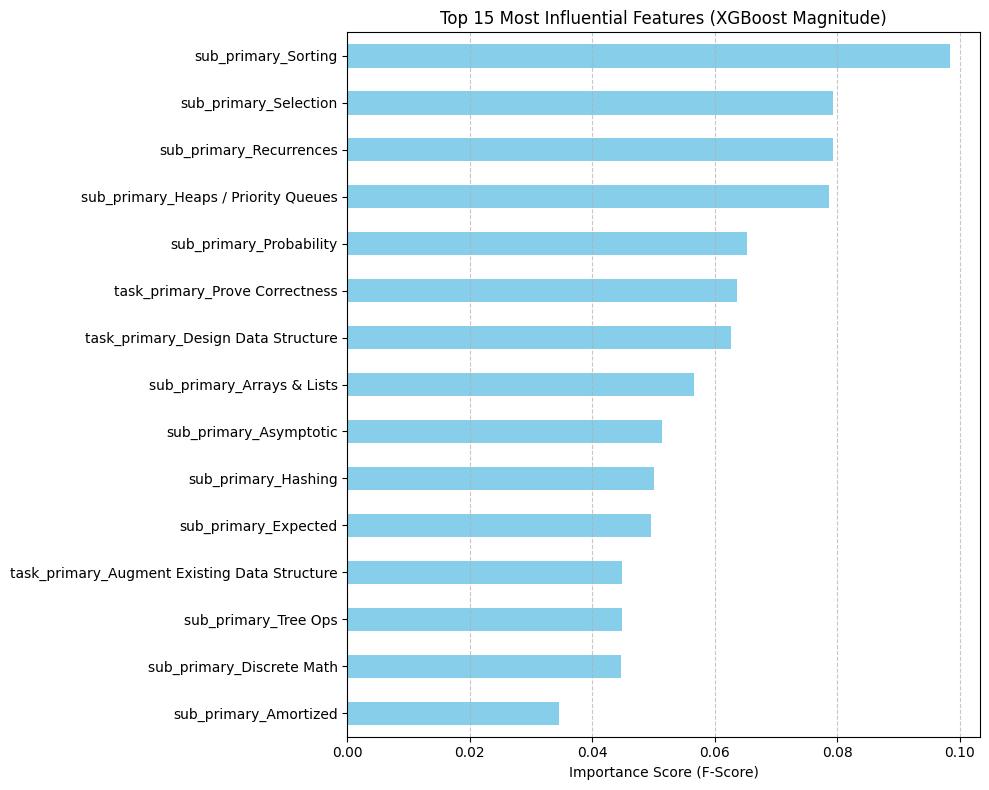

C:\Users\liaso\AppData\Local\Temp\ipykernel_40956\1622939196.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=top_and_bottom, palette='RdBu_r')


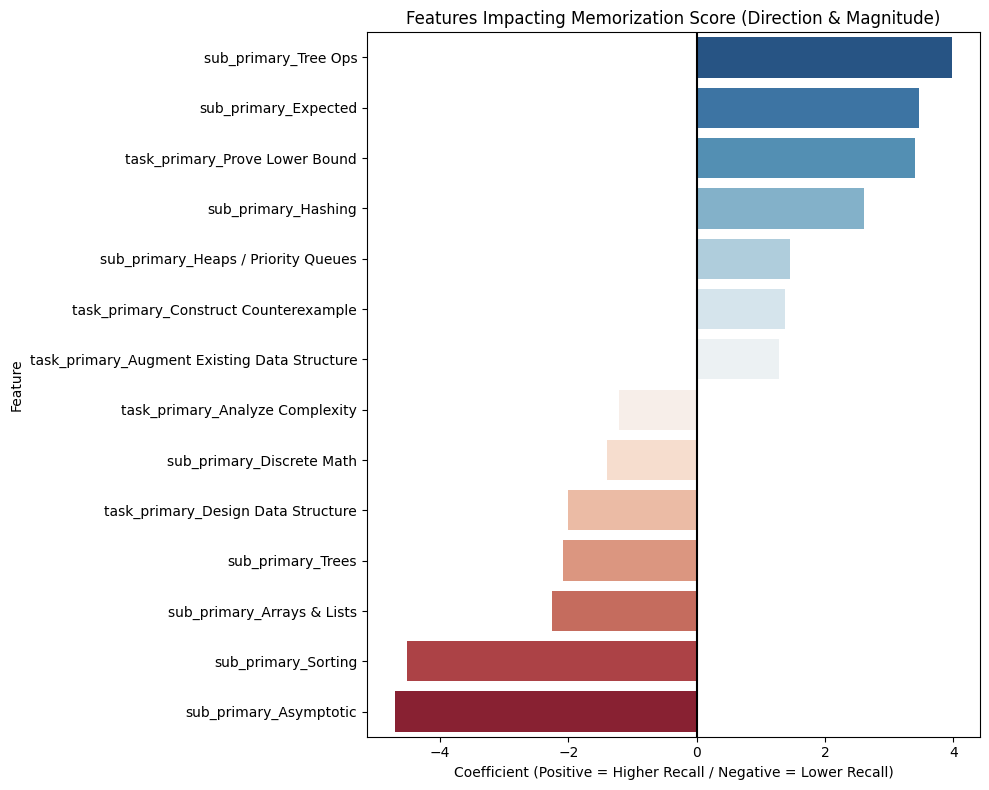

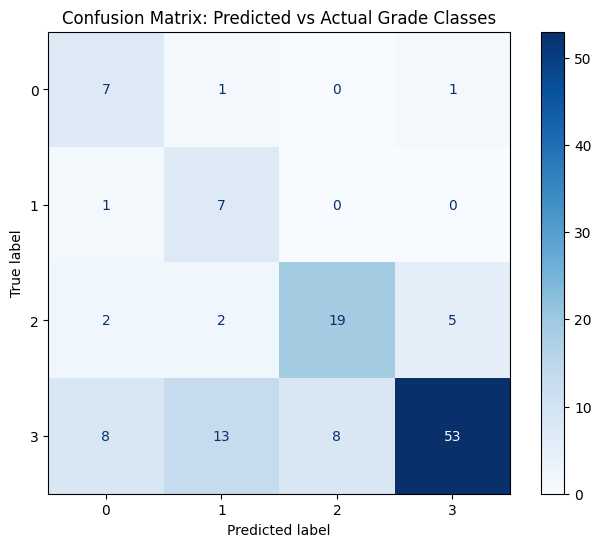

Cohen's Kappa Score: 0.4890


In [105]:
# --- 1. XGBoost Feature Importance (Magnitude) ---
# Access the classifier and feature names from the pipeline
clf = best_model.named_steps['clf']
# If your pipeline has PolynomialFeatures, get those names, otherwise use X.columns
if 'interactions' in best_model.named_steps:
    feature_names = best_model.named_steps['interactions'].get_feature_names_out(X.columns)
else:
    feature_names = X.columns

# Get importances and create a Series
importances = pd.Series(clf.feature_importances_, index=feature_names)

# Plot the Top 15 Features by Magnitude
plt.figure(figsize=(10, 8))
importances.nlargest(15).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title('Top 15 Most Influential Features (XGBoost Magnitude)')
plt.xlabel('Importance Score (F-Score)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('xgboost_feature_importance.png')
plt.show()

# --- 2. OLS Coefficients (Direction & Magnitude) ---
# This shows exactly which subjects INCREASE or DECREASE the score
ols_model = ols_pipeline.named_steps['model']
# For OLS, we use the original features to keep the explanation simple
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': ols_model.coef_})
coeff_df = coeff_df.sort_values(by='Coefficient', ascending=False)

# Select top 7 positive and top 7 negative features
top_and_bottom = pd.concat([coeff_df.head(7), coeff_df.tail(7)])

plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Feature', data=top_and_bottom, palette='RdBu_r')
plt.axvline(0, color='black', linestyle='-', lw=1.5)
plt.title('Features Impacting Memorization Score (Direction & Magnitude)')
plt.xlabel('Coefficient (Positive = Higher Recall / Negative = Lower Recall)')
plt.tight_layout()
plt.savefig('ols_coefficients_direction.png')
plt.show()

# --- 3. Performance Assessment: Confusion Matrix & Kappa ---
cm = confusion_matrix(y, y_pred_weighted)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Predicted vs Actual Grade Classes')
plt.savefig('confusion_matrix_weighted.png')
plt.show()

kappa = cohen_kappa_score(y, y_pred_weighted)
print(f"Cohen's Kappa Score: {kappa:.4f}")